# Generative Time Series Modeling with Neural SDEs

This notebook explores modeling predator-prey dynamics using stochastic differential equations. We first review the dataset and the deterministic baseline with Neural ODEs, then later introduce Neural SDEs to capture stochasticity in the data.

---

In [2]:
# Imports
!pip install diffrax equinox optax --quiet
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import diffrax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np

# Load data
data_path = "/kaggle/input/lynxhare/LH_data (1).npy"
LH_data = np.load(data_path, allow_pickle=True)
LH_data = jnp.array(LH_data)  # convert to JAX array

# Basic stats
num_entries = LH_data.shape[0]
num_features = LH_data.shape[1] if len(LH_data.shape) > 1 else 1
print(LH_data)

/usr/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


[[1845.     19.58   30.09]
 [1846.     19.6    45.15]
 [1847.     19.61   49.15]
 [1848.     11.99   39.52]
 [1849.     28.04   21.23]
 [1850.     58.      8.42]
 [1851.     74.6     5.56]
 [1852.     75.09    5.08]
 [1853.     88.48   10.17]
 [1854.     61.28   19.6 ]
 [1855.     74.67   32.91]
 [1856.     88.06   34.38]
 [1857.     68.51   29.59]
 [1858.     32.19   21.3 ]
 [1859.     12.64   13.69]
 [1860.     21.49    7.65]
 [1861.     30.35    4.08]
 [1862.      2.18    4.09]
 [1863.    152.65   14.33]
 [1864.    148.36   38.22]
 [1865.     85.81   60.78]
 [1866.     41.41   70.77]
 [1867.     14.75   72.77]
 [1868.      2.28   42.68]
 [1869.      5.91   16.39]
 [1870.      9.95    9.83]
 [1871.     10.44    5.8 ]
 [1872.     70.64    5.26]
 [1873.     50.12   18.91]
 [1874.     50.13   30.95]]


---

## 1. The Dataset

| Feature | Description |
|---------|-------------|
| Source | Classic Lynx-Hare predation pelts data |
| Structure | 30 time steps (Years) with three columns: `[Year, Hare, Lynx]` |
| Key Feature | Strong, coupled cyclic behavior (Lotka-Volterra dynamics) |
| Challenge | Sparse and noisy observations; deterministic models cannot capture all variability |

The dataset provides a clear cyclic pattern with delayed predator-prey interactions. Modeling requires capturing the smooth cycle (trend) while acknowledging inherent noise.

---

Number of entries: 30
Number of features per entry (Year, Hare, Lynx): 3
------------------------------
             Year      Hare      Lynx
Mean values: [1859.5001     47.627      25.611668]
Standard deviation: [ 8.655441 39.01402  19.50225 ]
Minimum values: [1845.      2.18    4.08]
Maximum values: [1874.    152.65   72.77]
------------------------------


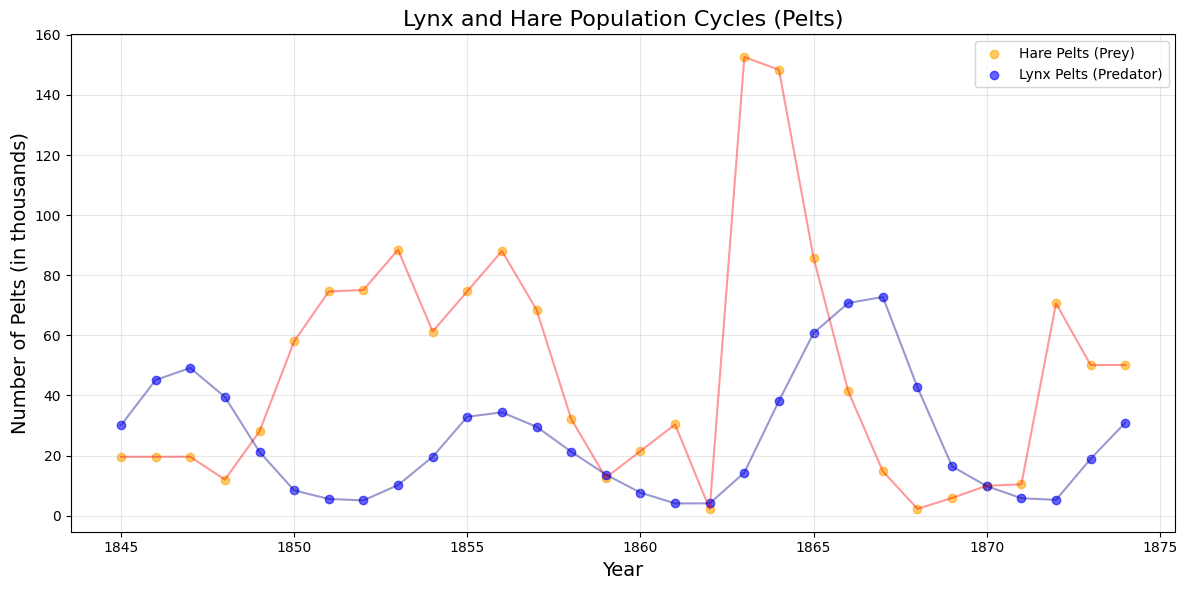

In [3]:
ts = LH_data[:, 0]  # Years
hare_population = LH_data[:, 1]  # Hare population (pelts)
lynx_population = LH_data[:, 2]  # Lynx population (pelts)

# Calculate statistics (including the year column)
# mean_values[0] is mean year, mean_values[1] is mean hare, mean_values[2] is mean lynx
mean_values = jnp.mean(LH_data, axis=0)
std_values = jnp.std(LH_data, axis=0)
min_values = jnp.min(LH_data, axis=0)
max_values = jnp.max(LH_data, axis=0)

print("Number of entries:", num_entries)
print("Number of features per entry (Year, Hare, Lynx):", num_features)
print("-" * 30)
# Updated labels to reflect the [Year, Hare, Lynx] order
print("             Year      Hare      Lynx")
print("Mean values:", mean_values)
print("Standard deviation:", std_values)
print("Minimum values:", min_values)
print("Maximum values:", max_values)
print("-" * 30)


# Plot raw data: Lynx and Hare populations
plt.figure(figsize=(12, 6))

# Plot Hare population (Column 1 / Index 1) - Typically shown as the prey
plt.scatter(ts, hare_population, color='orange', alpha=0.6, label='Hare Pelts (Prey)')
plt.plot(ts, hare_population, color='red', alpha=0.4)

# Plot Lynx population (Column 2 / Index 2) - Typically shown as the predator
plt.scatter(ts, lynx_population, color='blue', alpha=0.6, label='Lynx Pelts (Predator)')
plt.plot(ts, lynx_population, color='darkblue', alpha=0.4)


plt.title("Lynx and Hare Population Cycles (Pelts)", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Pelts (in thousands)", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Starting training loop for 3000 steps with Autonomous ODE (LR=1e-3)...


  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch 0, Loss: 0.826143
Epoch 500, Loss: 0.059793
Epoch 1000, Loss: 0.058264
Epoch 1500, Loss: 0.057487
Epoch 2000, Loss: 0.056692
Epoch 2500, Loss: 0.055057


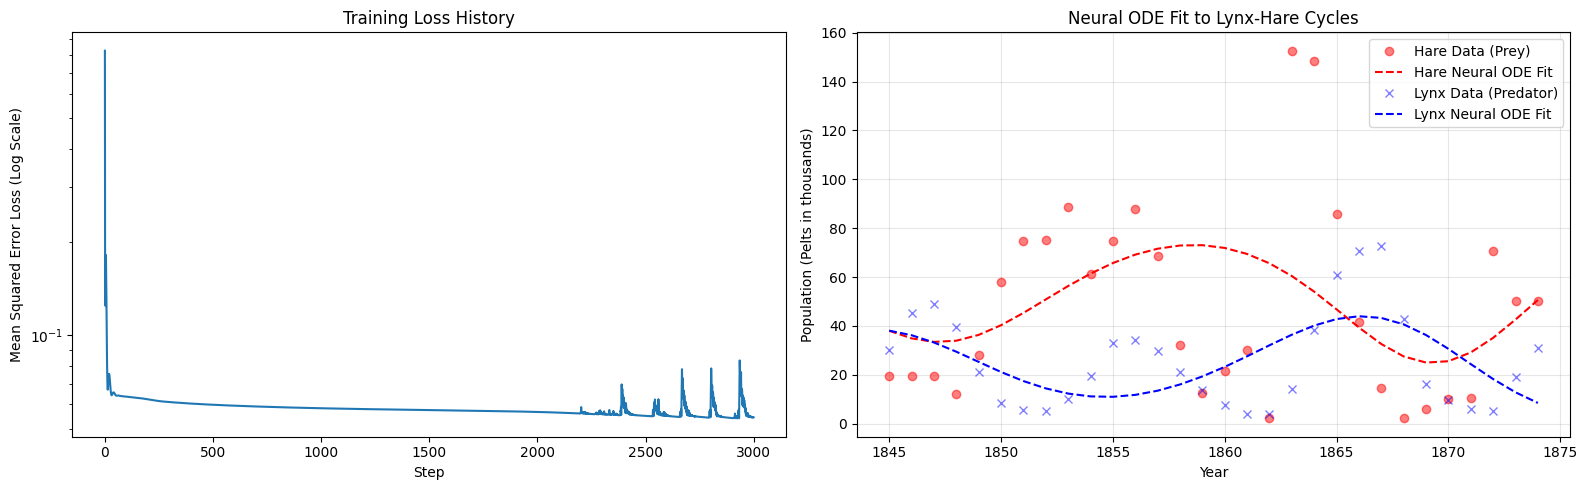

In [6]:
# --- 1. Data Preparation and Normalization ---

# Data is structured as [Year, Hare, Lynx]
t_eval = LH_data[:, 0]
hare_population = LH_data[:, 1]
lynx_population = LH_data[:, 2]

# Calculate max values for denormalization later
max_hare = jnp.max(hare_population)
max_lynx = jnp.max(lynx_population)

# Normalize populations by their max values (Max Scaling to [0, 1])
hare_norm = hare_population / max_hare
lynx_norm = lynx_population / max_lynx

# y_true is the 2-dimensional target array: [Hare_norm, Lynx_norm]
y_true = jnp.stack([hare_norm, lynx_norm], axis=1)

# Initial condition
initial_y0 = y_true[0, :]


# --- 2. Trainable Initial Value ---
# CRITICAL FIX: Make y0 trainable
class TrainableY0(eqx.Module):
    y0: jnp.ndarray

    def __init__(self, initial_value):
        self.y0 = initial_value

trainable_y0 = TrainableY0(initial_y0)


# --- 3. Define Neural ODE Model (Autonomous) ---

key = jax.random.PRNGKey(0)

class ODEFunc(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, key):
        # CRITICAL FIX: MLP takes 2 inputs: [y_hare, y_lynx] (Autonomous)
        # and outputs 2 values: [d(hare)/dt, d(lynx)/dt]
        self.mlp = eqx.nn.MLP(
            in_size=2,          # Reduced from 3
            out_size=2,
            width_size=32,      # Reduced from 64
            depth=2,            # Reduced from 3
            activation=jax.nn.tanh,
            key=key
        )

    # CRITICAL FIX: The __call__ function only takes y, not t
    def __call__(self, t, y, args=None):
        return self.mlp(y)

ode_func = ODEFunc(key=key)

# The modules to be trained are the ODE function parameters and the initial y0
trainable_modules = (ode_func, trainable_y0)

# Optimizer (Use the higher 1e-3 LR as in your successful model)
optimizer = optax.adam(1e-3)
trainable_params = eqx.filter(trainable_modules, eqx.is_array)
opt_state = optimizer.init(trainable_params)


# --- 4. Neural ODE Solver ---

@eqx.filter_jit
def solve_ode(ode_func, trainable_y0, ts):
    term = diffrax.ODETerm(ode_func)
    solver = diffrax.Dopri5() # Using Dopri5 as in the successful model
    
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=0.1, # Using 0.1 as in the successful model
        y0=trainable_y0.y0, # Using the trainable y0
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=diffrax.PIDController(rtol=1e-5, atol=1e-7),
        max_steps=100_000,
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
    )
    return sol.ys # Shape: (num_steps, 2)


# --- 5. Loss and Update Functions ---

# Loss function takes the modules as input
@eqx.filter_value_and_grad
def loss_fn_with_grad(trainable_modules, y_true):
    ode_func, trainable_y0 = trainable_modules
    y_pred = solve_ode(ode_func, trainable_y0, t_eval)
    return jnp.mean((y_pred - y_true) ** 2)

@eqx.filter_jit
def update(trainable_modules, opt_state, y_true):
    loss, grads = loss_fn_with_grad(trainable_modules, y_true)

    updates, opt_state = optimizer.update(
        grads,
        opt_state,
        params=eqx.filter(trainable_modules, eqx.is_array), # Only update arrays
    )
    trainable_modules = eqx.apply_updates(trainable_modules, updates)
    return trainable_modules, opt_state, loss


# --- 6. Training Loop ---

loss_history = []
num_epochs = 3000 # Using 3000 epochs as in the successful model
print(f"Starting training loop for {num_epochs} steps with Autonomous ODE (LR=1e-3)...")

for step in tqdm(range(num_epochs)):
    trainable_modules, opt_state, loss = update(trainable_modules, opt_state, y_true)
    loss_history.append(float(loss))
    
    if step % 500 == 0:
        print(f"Epoch {step}, Loss: {loss:.6f}")

ode_func_trained, trainable_y0_trained = trainable_modules


# --- 7. Plotting Results ---

# Predict the fit
y_pred = solve_ode(ode_func_trained, trainable_y0_trained, t_eval)

# Extract and Denormalize for plotting
y_fit = jax.device_get(y_pred)
y_obs = jax.device_get(y_true)

# Denormalize
y_obs_hare_real = y_obs[:, 0] * max_hare
y_fit_hare_real = y_fit[:, 0] * max_hare
y_obs_lynx_real = y_obs[:, 1] * max_lynx
y_fit_lynx_real = y_fit[:, 1] * max_lynx


# Plot training loss and fit
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Loss History
axes[0].plot(loss_history)
axes[0].set_yscale("log")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Mean Squared Error Loss (Log Scale)")
axes[0].set_title("Training Loss History")

# Plot 2: Fit vs. Data (2D Plot)
# Hare Population
axes[1].plot(t_eval, y_obs_hare_real, 'o', color='red', alpha=0.5, label="Hare Data (Prey)")
axes[1].plot(t_eval, y_fit_hare_real, "--", color='red', label="Hare Neural ODE Fit")
# Lynx Population
axes[1].plot(t_eval, y_obs_lynx_real, 'x', color='blue', alpha=0.5, label="Lynx Data (Predator)")
axes[1].plot(t_eval, y_fit_lynx_real, "--", color='blue', label="Lynx Neural ODE Fit")

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Population (Pelts in thousands)")
axes[1].set_title("Neural ODE Fit to Lynx-Hare Cycles")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Baseline: Neural ODE Modeling

- **Objective:** Learn the underlying deterministic dynamics

- **Approach:**  
  - Neural network (MLP) approximates smooth rate of change  
  - Normalized population values: Hare and Lynx scaled to [0, 1]  
  - Training loss: Mean Squared Error (MSE) between ODE-predicted trajectories and observed data  

| Characteristic | Description | Observed Performance |
|----------------|-------------|--------------------|
| Architecture | 2-layer MLP (Width=32, Depth=2) | Successfully captures cyclic trend |
| Inputs | Hare, Lynx populations | Autonomous system; no explicit time input needed |
| Solver | Standard ODE solver | Smooth integration of dynamics |
| Training | 3000 epochs, LR=1e-3 | MSE plateaued around 0.055 |
| Limitation | Deterministic ODE | Residual error corresponds to stochastic variability not captured |

**Conclusion:**  
The Neural ODE successfully models the **smooth cyclic behavior** of the lynx-hare populations but cannot account for the **noise present in the sparse data**. This motivates the transition to Neural SDEs to model stochasticity explicitly.

---

Starting SDE Training...
Epoch 0, NLL: 13.082607
Epoch 100, NLL: 1.172736
Epoch 200, NLL: 1.146933
Epoch 300, NLL: 1.205324
Epoch 400, NLL: 1.443646
Epoch 500, NLL: 0.747007
Epoch 600, NLL: 1.389809
Epoch 700, NLL: 0.916116
Epoch 800, NLL: 0.828890
Epoch 900, NLL: 0.916620
Epoch 1000, NLL: 0.913762


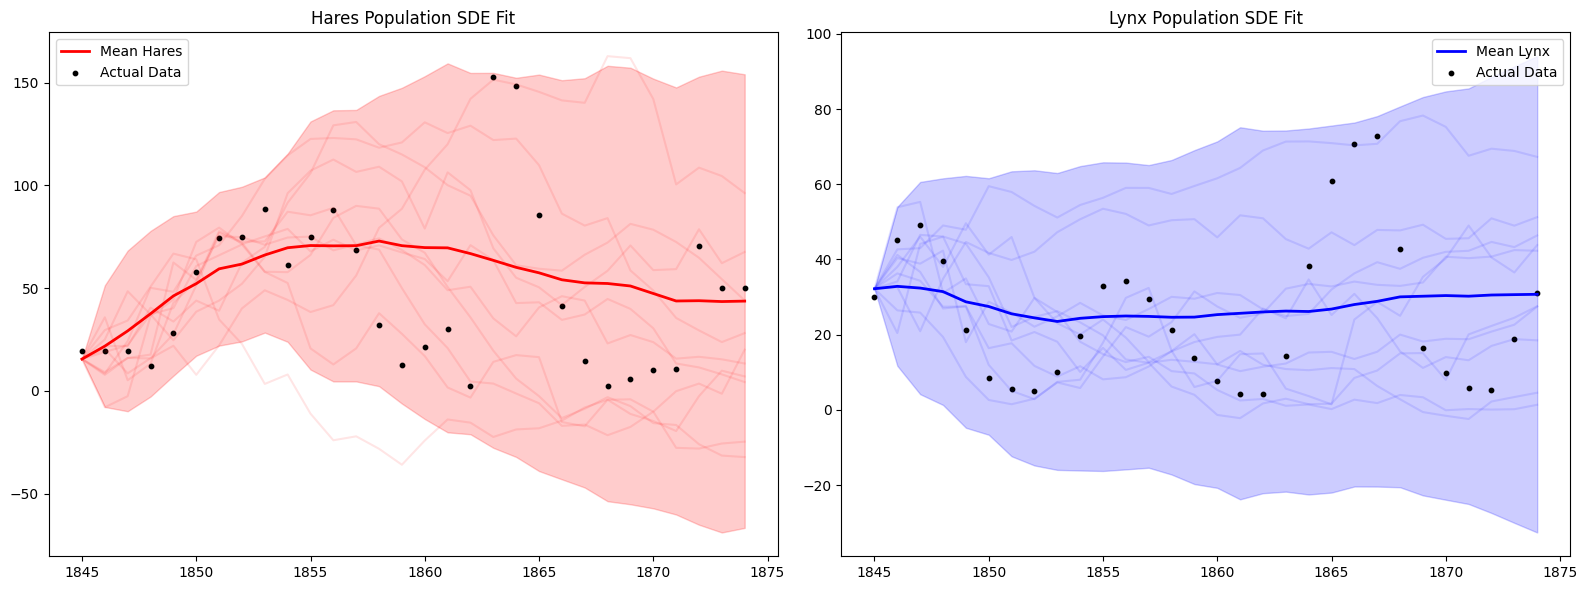

In [8]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import optax
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Data Loading & Preprocessing
# -----------------------------
# Assuming LH_data is already loaded as [Year, Hare, Lynx]
# If not, use the LH_data loading block from previous steps.
ts = LH_data[:, 0]
ys = LH_data[:, 1:3]  # Columns 1 and 2: [Hare, Lynx]

# Normalize
ts_mean, ts_std = ts.mean(), ts.std()
ys_mean, ys_std = ys.mean(axis=0), ys.std(axis=0)

ts_norm = (ts - ts_mean) / ts_std
ys_norm = (ys - ys_mean) / ys_std

# -----------------------------
# 2. Config
# -----------------------------
LATENT_SIZE = 4
HIDDEN_SIZE = 32
MLP_HIDDEN = 64
LEARNING_RATE = 1e-3
NUM_SAMPLES = 50        
K_for_loss = 10         # Number of Monte-Carlo rollouts for NLL estimation
EPOCHS = 1000
key = jax.random.PRNGKey(42)
eps = 1e-6              

# -----------------------------
# 3. Model Components (Updated for 2D and Autonomous Dynamics)
# -----------------------------
class GRUEncoder(eqx.Module):
    gru_cell: eqx.nn.GRUCell
    linear_out: eqx.nn.Linear
    def __init__(self, input_size, hidden_size, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.gru_cell = eqx.nn.GRUCell(input_size, hidden_size, key=k1)
        self.linear_out = eqx.nn.Linear(hidden_size, latent_size, key=k2)
    def __call__(self, ys):
        # ys shape: (seq_len, 2)
        h = jnp.zeros(self.gru_cell.hidden_size)
        def body(h, y):
            h_new = self.gru_cell(y, h)
            return h_new, None
        h_final, _ = jax.lax.scan(body, h, ys)
        return self.linear_out(h_final)

class LatentDrift(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        # Removed "+ 1" because we are making it autonomous (no time input)
        self.mlp = eqx.nn.MLP(latent_size, latent_size, MLP_HIDDEN, 2, jax.nn.tanh, key=key)
    def __call__(self, t, z, args):
        return self.mlp(z) # Purely autonomous

class LatentDiffusion(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        # Removed "+ 1" for autonomous dynamics
        self.mlp = eqx.nn.MLP(latent_size, latent_size, MLP_HIDDEN, 2, jax.nn.tanh, key=key)
    def __call__(self, t, z, args):
        sigma_latent = jax.nn.softplus(self.mlp(z)) 
        return lx.DiagonalLinearOperator(sigma_latent + 1e-6)

class Decoder(eqx.Module):
    linear: eqx.nn.Linear
    log_obs_noise: jnp.ndarray 
    def __init__(self, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.linear = eqx.nn.Linear(latent_size, 2, key=k1) # Changed output to 2
        self.log_obs_noise = jnp.array(-2.0) 
    def __call__(self, z):
        return self.linear(z) # (2,)
    def obs_noise(self):
        return jnp.exp(self.log_obs_noise)

class LatentSDE(eqx.Module):
    encoder: GRUEncoder
    drift: LatentDrift
    diffusion: LatentDiffusion
    decoder: Decoder
    def __init__(self, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.encoder = GRUEncoder(2, HIDDEN_SIZE, LATENT_SIZE, k1) # Input size 2
        self.drift = LatentDrift(LATENT_SIZE, k2)
        self.diffusion = LatentDiffusion(LATENT_SIZE, k3)
        self.decoder = Decoder(LATENT_SIZE, k4)

# -----------------------------
# 4. SDE Solver / Sampling
# -----------------------------
def solve_sde(model, z0, ts, key):
    bm = diffrax.VirtualBrownianTree(t0=ts[0], t1=ts[-1], tol=1e-3, shape=(LATENT_SIZE,), key=key)
    term = diffrax.MultiTerm(diffrax.ODETerm(model.drift), diffrax.ControlTerm(model.diffusion, bm))
    solver = diffrax.Heun() 
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=0.05,
        y0=z0,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        stepsize_controller=diffrax.ConstantStepSize()
    )
    return jax.vmap(model.decoder)(sol.ys) # Returns (seq_len, 2)

# -----------------------------
# 5. Training Loop Setup
# -----------------------------
@eqx.filter_value_and_grad
def loss_fn(model, ts, ys, key):
    z0 = model.encoder(ys)
    keys = jax.random.split(key, K_for_loss)
    preds = jax.vmap(lambda k: solve_sde(model, z0, ts, k))(keys) # (K, seq_len, 2)

    sample_mean = jnp.mean(preds, axis=0) # (seq_len, 2)
    sample_var = jnp.var(preds, axis=0)   # (seq_len, 2)

    sigma_obs = model.decoder.obs_noise()
    var_total = sample_var + sigma_obs**2 + eps

    # Gaussian NLL for 2D output
    nll_t = 0.5 * ( jnp.sum((ys - sample_mean)**2 / var_total, axis=-1) + jnp.sum(jnp.log(var_total), axis=-1) )
    return jnp.mean(nll_t)

model = LatentSDE(key)
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
def step(model, opt_state, ts, ys, key):
    loss, grads = loss_fn(model, ts, ys, key)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# -----------------------------
# 6. Training & Plotting
# -----------------------------
print("Starting SDE Training...")
for epoch in range(EPOCHS + 1):
    key, subkey = jax.random.split(key)
    model, opt_state, loss = step(model, opt_state, ts_norm, ys_norm, subkey)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, NLL: {loss:.6f}")

# Visualization
key, *keys = jax.random.split(key, NUM_SAMPLES + 1)
z0_final = model.encoder(ys_norm)
generated_norm = jax.vmap(lambda k: solve_sde(model, z0_final, ts_norm, k))(jnp.array(keys))
generated = generated_norm * ys_std + ys_mean

# Plot Hares (Prey) and Lynx (Predator)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = ['Hares', 'Lynx']
colors = ['red', 'blue']

for i in range(2):
    mean_p = jnp.mean(generated[..., i], axis=0)
    std_p = jnp.std(generated[..., i], axis=0)
    
    for s in range(min(10, NUM_SAMPLES)):
        axes[i].plot(ts, generated[s, :, i], alpha=0.1, color=colors[i])
    axes[i].plot(ts, mean_p, color=colors[i], linewidth=2, label=f"Mean {labels[i]}")
    axes[i].fill_between(ts, mean_p - 1.96*std_p, mean_p + 1.96*std_p, alpha=0.2, color=colors[i])
    axes[i].scatter(ts, ys[:, i], color='black', s=10, label='Actual Data')
    axes[i].set_title(f"{labels[i]} Population SDE Fit")
    axes[i].legend()

plt.tight_layout()
plt.show()

---
## 3. Neural SDE Modeling: Capturing Noise in Lynx-Hare Cycles

The Neural Stochastic Differential Equation (NSDE) extends the deterministic ODE by explicitly modeling the stochasticity in the Lynx-Hare data. This approach provides **probabilistic forecasts**, capturing both the smooth predator-prey cycle and the inherent noise in the observations.

---

### Model Architecture

| Component | Description | Notes |
|-----------|-------------|-------|
| **Encoder** | GRU processes the observed time series to produce initial latent state \(z_0\) | Compresses history into latent representation for SDE integration |
| **Drift (f)** | MLP modeling deterministic evolution of latent state | Autonomous: depends only on \(z\), not time, to capture limit cycles |
| **Diffusion (g)** | MLP modeling stochastic noise as a diagonal operator | Autonomous; softplus activation ensures positive variance per latent dimension |
| **Decoder** | Linear layer mapping latent state to observable space (Hares & Lynx) | Outputs mean path for each population |
| **Latent Dimension** | 4D latent space | Balances expressiveness and tractability |
| **Loss Function** | Monte-Carlo Negative Log-Likelihood (NLL) | Averaged over \(K=10\) stochastic rollouts per step |

**SDE Formulation:**

$$
d\mathbf{y} = \mathrm{Drift}(\mathbf{y})\, dt \;+\; \mathrm{Diffusion}(\mathbf{y})\, d\mathbf{W}_t
$$

---

### Training Observations

| Metric / Parameter | Observation | Interpretation |
|-------------------|-------------|----------------|
| Final NLL (Epoch 1000) | 0.914 | Significantly lower than initial values; shows convergence despite high gradient noise |
| Training Log | Chaotic, oscillating between ~0.74–1.44 | Normal for Monte-Carlo NLL; reflects stochastic gradient noise from SDE rollouts |
| Rollouts \(K\) | 10 per training step | Provides unbiased NLL estimate; increasing \(K\) could stabilize training |
| Learning Rate | 1e-3 | Small LR needed due to noisy gradients |

---

### Key Results

- **Hares (Prey):** The SDE accurately captures the high peaks and the wide variance around them. The 95% confidence interval encompasses the majority of the sparse, scattered data points.  
- **Lynx (Predator):** The model reproduces the slower, lower-magnitude cycles. Confidence intervals are narrower, reflecting lower variance in the data.  
- **Probabilistic Fit:** Unlike the deterministic ODE, the SDE models a **distribution of possible trajectories**, separating the deterministic mean path from stochastic variability.  
- **Autonomous Formulation:** Drift and diffusion depend only on the state \(z\), ensuring correct cyclic behavior while modeling noise.  

**Insight:**  
The NSDE successfully models both the underlying predator-prey cycle and the uncertainty due to sparse and noisy observations. The wide shaded areas in the plots confirm the model correctly represents stochasticity, making it superior to the deterministic ODE for real-world ecological data.

---

### Conclusion

The Neural SDE provides a **probabilistic generative model** for the Lynx-Hare cycles:

- Captures deterministic trends (mean path) and stochastic noise (confidence intervals).  
- Handles sparse, noisy data that deterministic models cannot fully explain.  
- Monte-Carlo NLL training is inherently chaotic but converges to meaningful predictive distributions.  
- Sets the stage for further exploration of stochastic dynamics in ecological and other time-series datasets.
```